In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.2 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import re
import glob
import random
import yaml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns

import IPython.display as display
from PIL import Image
import cv2

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
def display_image(image, print_info = True, hide_axis = False):
    if isinstance(image, str):  # Check if it's a file path
        img = Image.open(image)
        plt.imshow(img)
    elif isinstance(image, np.ndarray):  # Check if it's a NumPy array
        image = image[..., ::-1]  # BGR to RGB
        img = Image.fromarray(image)
        plt.imshow(img)
    else:
        raise ValueError("Unsupported image format")

    if print_info:
        print('Type: ', type(img), '\n')
        print('Shape: ', np.array(img).shape, '\n')

    if hide_axis:
        plt.axis('off')

    plt.show()

Type:  <class 'PIL.JpegImagePlugin.JpegImageFile'> 

Shape:  (956, 1300, 3) 



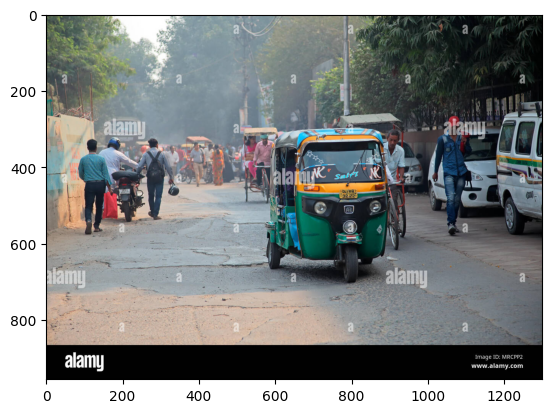

In [ ]:
example_image_path = '/content/sddasda.jpg'
display_image(example_image_path, print_info = True, hide_axis = False)

In [ ]:
model = YOLO('yolov8s.pt')

results = model.predict(
    source = example_image_path,
    conf = 0.40,
      # or "cpu" if no GPU
    imgsz = (956,1300),
    save = True,
    save_txt = True,
    save_conf = True,
    exist_ok = True,
)


WARNING ⚠️ imgsz=[956, 1300] must be multiple of max stride 32, updating to [960, 1312]
image 1/1 /content/sddasda.jpg: 960x1312 12 persons, 2 bicycles, 3 cars, 1 motorcycle, 2 trucks, 1 backpack, 1905.3ms
Speed: 24.2ms preprocess, 1905.3ms inference, 4.0ms postprocess per image at shape (1, 3, 960, 1312)
Results saved to /content/runs/detect/predict
2 labels saved to /content/runs/detect/predict/labels


Type:  <class 'PIL.JpegImagePlugin.JpegImageFile'> 

Shape:  (956, 1300, 3) 



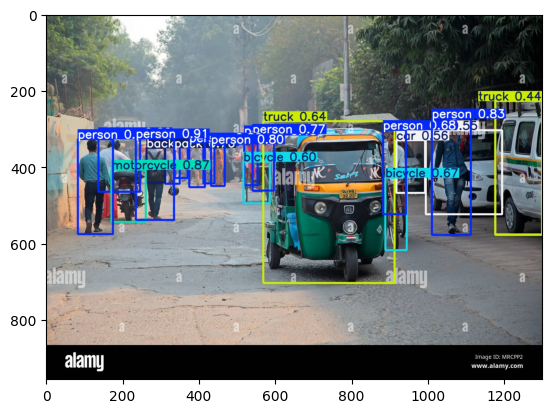

In [ ]:
example_image_inference_output = example_image_path.split('/')[-1]
display_image(f'/content/runs/detect/predict/{example_image_inference_output}')